In [ ]:
"C:\Users\91944\Downloads\fake reviews dataset.csv\fake reviews dataset.csv"

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings, string
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

In [5]:
df = pd.read_csv('fake reviews dataset.csv')
df.head()

,category,rating,label,text_
0,Home_and_Kitchen_5,5.0,CG,"Love this! Well made, sturdy, and very comfor..."
1,Home_and_Kitchen_5,5.0,CG,"love it, a great upgrade from the original. I..."
2,Home_and_Kitchen_5,5.0,CG,This pillow saved my back. I love the look and...
3,Home_and_Kitchen_5,1.0,CG,"Missing information on how to use it, but it i..."
4,Home_and_Kitchen_5,5.0,CG,Very nice set. Good quality. We have had the s...


In [7]:
df.head()

,category,rating,label,text_
0,Home_and_Kitchen_5,5.0,CG,"Love this! Well made, sturdy, and very comfor..."
1,Home_and_Kitchen_5,5.0,CG,"love it, a great upgrade from the original. I..."
2,Home_and_Kitchen_5,5.0,CG,This pillow saved my back. I love the look and...
3,Home_and_Kitchen_5,1.0,CG,"Missing information on how to use it, but it i..."
4,Home_and_Kitchen_5,5.0,CG,Very nice set. Good quality. We have had the s...


In [8]:
df.dropna(inplace=True)

In [9]:
df['length'] = df['text_'].apply(len)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40432 entries, 0 to 40431
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   category  40432 non-null  object 
 1   rating    40432 non-null  float64
 2   label     40432 non-null  object 
 3   text_     40432 non-null  object 
 4   length    40432 non-null  int64  
dtypes: float64(1), int64(1), object(3)
memory usage: 1.5+ MB


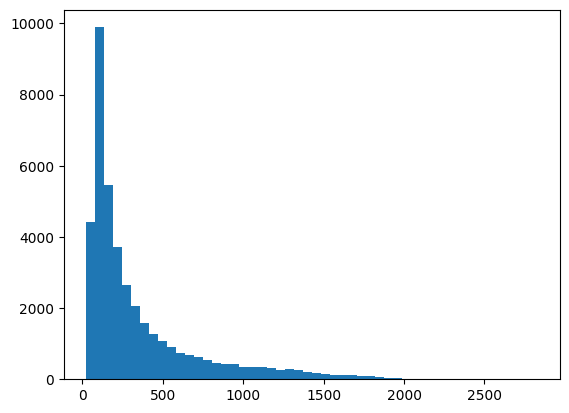

In [11]:
plt.hist(df['length'],bins=50)
plt.show()

In [12]:
df.groupby('label').describe()

rating                                                length  \
         count      mean       std  min  25%  50%  75%  max    count   
label                                                                  
CG     20216.0  4.259893  1.141065  1.0  4.0  5.0  5.0  5.0  20216.0   
OR     20216.0  4.253265  1.147652  1.0  4.0  5.0  5.0  5.0  20216.0   

                                                                  
             mean         std   min    25%    50%    75%     max  
label                                                             
CG     305.573506  307.037430  24.0   96.0  174.0  383.0  1717.0  
OR     396.970419  418.428047  28.0  121.0  224.0  498.0  2827.0

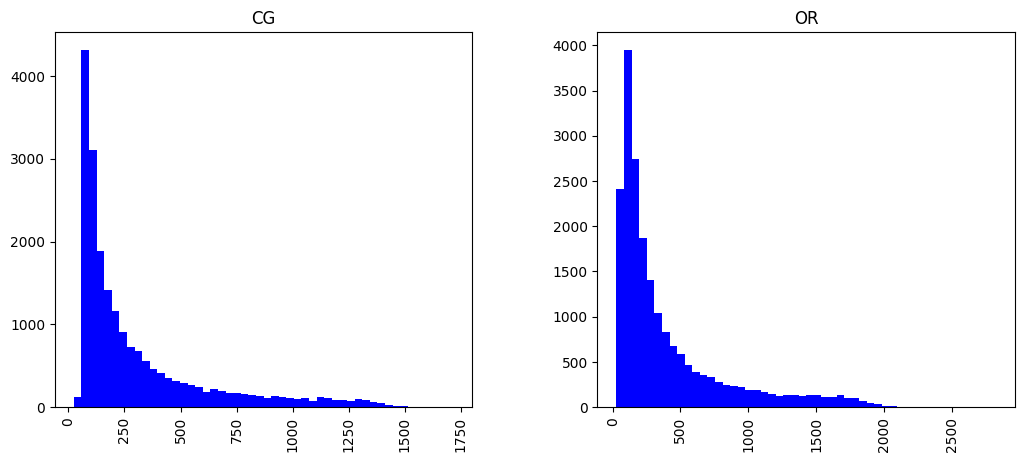

In [13]:
df.hist(column='length',by='label',bins=50,color='blue',figsize=(12,5))
plt.show()

In [14]:
df[df['label']=='OR'][['text_','length']].sort_values(by='length',ascending=False).head().iloc[0].text_

'WEAK ON CURRENT SCIENCE.\nAfter seeing it twice, I agree with much (but not all) of the positive five star reviews. Out of respect for those who READ reviews, I\'ll not repeat everything that I like about the presentation. I found the goofy oversize earrings, hairdo, and facial hair arrangement of Daniel Vitalis, (described as a "Wild Food Expert") distracting. UGH. Ditto for David Wolfe, who had an extremely goofy wild hairdo. On the other hand, Jon Gabriel, described as an "author and weight loss expert" was nicely groomed and a good presenter. His story of personal transformation of a fellow of over 400 pounds (whew) to becoming a jock of normal weight was inspiring. Christiane Northrup preserves her rank as one of America\'s cutest doctors. A really nice looking woman! Presentations by Dr. Mercola, Jason Vale, Kris Carr, Alejandro Junger were fine. It was disappointing to have Jamie Oliver (so popular in the UK) give Baby Cow Growth Fluid a pass with unscientific but popular ideas

In [15]:
df.length.describe()

,length
count,40432.000000
mean,351.271963
std,369.813570
min,24.000000
25%,107.000000
50%,198.000000
75%,439.000000
max,2827.000000


In [16]:
def text_process(review):
    nopunc = [char for char in review if char not in string.punctuation]
    nopunc = ''.join(nopunc)
    return [word for word in nopunc.split() if word.lower() not in stopwords.words('english')]

In [17]:
bow_transformer = CountVectorizer(analyzer=text_process)
bow_transformer

CountVectorizer(analyzer=<function text_process at 0x79c3cdff5c60>)

In [19]:
import nltk
nltk.download('stopwords')
bow_transformer.fit(df['text_'])
print("Total Vocabulary:",len(bow_transformer.vocabulary_))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


Total Vocabulary: 61612


In [20]:
review4 = df['text_'][3]
review4

'Missing information on how to use it, but it is a great product for the price!  I'

In [21]:
bow_msg4 = bow_transformer.transform([review4])
print(bow_msg4)
print(bow_msg4.shape)

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 6 stored elements and shape (1, 61612)>
  Coords	Values
  (0, 15403)	1
  (0, 38385)	1
  (0, 41023)	1
  (0, 49181)	1
  (0, 49370)	1
  (0, 59397)	1
(1, 61612)


In [23]:
print(bow_transformer.get_feature_names_out()[15841])
print(bow_transformer.get_feature_names_out()[23848])

NOnly
Warricks


In [24]:
bow_reviews = bow_transformer.transform(df['text_'])

In [25]:
print("Shape of Bag of Words Transformer for the entire reviews corpus:",bow_reviews.shape)
print("Amount of non zero values in the bag of words model:",bow_reviews.nnz)

Shape of Bag of Words Transformer for the entire reviews corpus: (40432, 61612)
Amount of non zero values in the bag of words model: 1071779


In [26]:
print("Sparsity:",np.round((bow_reviews.nnz/(bow_reviews.shape[0]*bow_reviews.shape[1]))*100,2))

Sparsity: 0.04


In [27]:
tfidf_transformer = TfidfTransformer().fit(bow_reviews)
tfidf_rev4 = tfidf_transformer.transform(bow_msg4)
print(bow_msg4)

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 6 stored elements and shape (1, 61612)>
  Coords	Values
  (0, 15403)	1
  (0, 38385)	1
  (0, 41023)	1
  (0, 49181)	1
  (0, 49370)	1
  (0, 59397)	1


In [28]:
print(tfidf_transformer.idf_[bow_transformer.vocabulary_['mango']])
print(tfidf_transformer.idf_[bow_transformer.vocabulary_['book']])

10.914254381647021
2.9117275133827123


In [29]:
tfidf_reviews = tfidf_transformer.transform(bow_reviews)
print("Shape:",tfidf_reviews.shape)
print("No. of Dimensions:",tfidf_reviews.ndim)

Shape: (40432, 61612)
No. of Dimensions: 2


**Creating training and testing data**

In [30]:
review_train, review_test, label_train, label_test = train_test_split(df['text_'],df['label'],test_size=0.35)

In [31]:
pipeline = Pipeline([
    ('bow',CountVectorizer(analyzer=text_process)),
    ('tfidf',TfidfTransformer()),
    ('classifier',MultinomialNB())
])

**Training and testing Multinomial Naive Bayes Algorithm on the preprocessed data**

In [32]:
pipeline.fit(review_train,label_train)

Pipeline(steps=[('bow',
                 CountVectorizer(analyzer=<function text_process at 0x79c3cdff5c60>)),
                ('tfidf', TfidfTransformer()),
                ('classifier', MultinomialNB())])

In [33]:
predictions = pipeline.predict(review_test)
predictions

array(['CG', 'OR', 'CG', ..., 'CG', 'OR', 'OR'], dtype='<U2')

In [34]:
print('Classification Report:',classification_report(label_test,predictions))
print('Confusion Matrix:',confusion_matrix(label_test,predictions))
print('Accuracy Score:',accuracy_score(label_test,predictions))

Classification Report:               precision    recall  f1-score   support

          CG       0.83      0.92      0.87      7101
          OR       0.91      0.81      0.86      7051

    accuracy                           0.86     14152
   macro avg       0.87      0.86      0.86     14152
weighted avg       0.87      0.86      0.86     14152

Confusion Matrix: [[6512  589]
 [1324 5727]]
Accuracy Score: 0.8648247597512719


In [35]:
print('Model Prediction Accuracy:',str(np.round(accuracy_score(label_test,predictions)*100,2)) + '%')

Model Prediction Accuracy: 86.48%


In [36]:
pipeline = Pipeline([
    ('bow',CountVectorizer(analyzer=text_process)),
    ('tfidf',TfidfTransformer()),
    ('classifier',RandomForestClassifier())
])

In [37]:
pipeline.fit(review_train,label_train)

Pipeline(steps=[('bow',
                 CountVectorizer(analyzer=<function text_process at 0x79c3cdff5c60>)),
                ('tfidf', TfidfTransformer()),
                ('classifier', RandomForestClassifier())])

In [38]:
rfc_pred = pipeline.predict(review_test)
rfc_pred

array(['CG', 'OR', 'CG', ..., 'CG', 'OR', 'OR'], dtype=object)

In [39]:
print('Classification Report:',classification_report(label_test,rfc_pred))
print('Confusion Matrix:',confusion_matrix(label_test,rfc_pred))
print('Accuracy Score:',accuracy_score(label_test,rfc_pred))
print('Model Prediction Accuracy:',str(np.round(accuracy_score(label_test,rfc_pred)*100,2)) + '%')

Classification Report:               precision    recall  f1-score   support

          CG       0.82      0.91      0.86      7101
          OR       0.90      0.80      0.85      7051

    accuracy                           0.86     14152
   macro avg       0.86      0.86      0.86     14152
weighted avg       0.86      0.86      0.86     14152

Confusion Matrix: [[6484  617]
 [1423 5628]]
Accuracy Score: 0.8558507631430187
Model Prediction Accuracy: 85.59%


In [40]:
pipeline = Pipeline([
    ('bow',CountVectorizer(analyzer=text_process)),
    ('tfidf',TfidfTransformer()),
    ('classifier',DecisionTreeClassifier())
])

In [41]:
pipeline.fit(review_train,label_train)

Pipeline(steps=[('bow',
                 CountVectorizer(analyzer=<function text_process at 0x79c3cdff5c60>)),
                ('tfidf', TfidfTransformer()),
                ('classifier', DecisionTreeClassifier())])

In [42]:
dtree_pred = pipeline.predict(review_test)
dtree_pred

array(['CG', 'OR', 'CG', ..., 'CG', 'OR', 'OR'], dtype=object)

In [43]:
print('Classification Report:',classification_report(label_test,dtree_pred))
print('Confusion Matrix:',confusion_matrix(label_test,dtree_pred))
print('Accuracy Score:',accuracy_score(label_test,dtree_pred))
print('Model Prediction Accuracy:',str(np.round(accuracy_score(label_test,dtree_pred)*100,2)) + '%')

Classification Report:               precision    recall  f1-score   support

          CG       0.75      0.78      0.76      7101
          OR       0.77      0.74      0.75      7051

    accuracy                           0.76     14152
   macro avg       0.76      0.76      0.76     14152
weighted avg       0.76      0.76      0.76     14152

Confusion Matrix: [[5529 1572]
 [1830 5221]]
Accuracy Score: 0.7596099491237988
Model Prediction Accuracy: 75.96%


In [44]:
pipeline = Pipeline([
    ('bow',CountVectorizer(analyzer=text_process)),
    ('tfidf',TfidfTransformer()),
    ('classifier',KNeighborsClassifier(n_neighbors=2))
])

In [45]:
pipeline.fit(review_train,label_train)

Pipeline(steps=[('bow',
                 CountVectorizer(analyzer=<function text_process at 0x79c3cdff5c60>)),
                ('tfidf', TfidfTransformer()),
                ('classifier', KNeighborsClassifier(n_neighbors=2))])

In [46]:
knn_pred = pipeline.predict(review_test)
knn_pred

array(['CG', 'CG', 'CG', ..., 'CG', 'CG', 'CG'], dtype=object)

In [47]:
print('Classification Report:',classification_report(label_test,knn_pred))
print('Confusion Matrix:',confusion_matrix(label_test,knn_pred))
print('Accuracy Score:',accuracy_score(label_test,knn_pred))
print('Model Prediction Accuracy:',str(np.round(accuracy_score(label_test,knn_pred)*100,2)) + '%')

Classification Report:               precision    recall  f1-score   support

          CG       0.50      1.00      0.67      7101
          OR       0.50      0.00      0.00      7051

    accuracy                           0.50     14152
   macro avg       0.50      0.50      0.33     14152
weighted avg       0.50      0.50      0.34     14152

Confusion Matrix: [[7097    4]
 [7047    4]]
Accuracy Score: 0.5017665347654042
Model Prediction Accuracy: 50.18%


In [48]:
pipeline = Pipeline([
    ('bow',CountVectorizer(analyzer=text_process)),
    ('tfidf',TfidfTransformer()),
    ('classifier',SVC())
])

In [49]:
pipeline.fit(review_train,label_train)

Pipeline(steps=[('bow',
                 CountVectorizer(analyzer=<function text_process at 0x79c3cdff5c60>)),
                ('tfidf', TfidfTransformer()), ('classifier', SVC())])

In [50]:
svc_pred = pipeline.predict(review_test)
svc_pred

array(['CG', 'OR', 'CG', ..., 'CG', 'OR', 'OR'], dtype=object)

In [51]:
print('Classification Report:',classification_report(label_test,svc_pred))
print('Confusion Matrix:',confusion_matrix(label_test,svc_pred))
print('Accuracy Score:',accuracy_score(label_test,svc_pred))
print('Model Prediction Accuracy:',str(np.round(accuracy_score(label_test,svc_pred)*100,2)) + '%')

Classification Report:               precision    recall  f1-score   support

          CG       0.92      0.87      0.90      7101
          OR       0.88      0.92      0.90      7051

    accuracy                           0.90     14152
   macro avg       0.90      0.90      0.90     14152
weighted avg       0.90      0.90      0.90     14152

Confusion Matrix: [[6195  906]
 [ 541 6510]]
Accuracy Score: 0.8977529677784059
Model Prediction Accuracy: 89.78%


In [52]:
pipeline = Pipeline([
    ('bow',CountVectorizer(analyzer=text_process)),
    ('tfidf',TfidfTransformer()),
    ('classifier',LogisticRegression())
])

In [53]:
pipeline.fit(review_train,label_train)

Pipeline(steps=[('bow',
                 CountVectorizer(analyzer=<function text_process at 0x79c3cdff5c60>)),
                ('tfidf', TfidfTransformer()),
                ('classifier', LogisticRegression())])

In [54]:
lr_pred = pipeline.predict(review_test)
lr_pred

array(['CG', 'OR', 'CG', ..., 'CG', 'OR', 'OR'], dtype=object)

In [55]:
print('Classification Report:',classification_report(label_test,lr_pred))
print('Confusion Matrix:',confusion_matrix(label_test,lr_pred))
print('Accuracy Score:',accuracy_score(label_test,lr_pred))
print('Model Prediction Accuracy:',str(np.round(accuracy_score(label_test,lr_pred)*100,2)) + '%')

Classification Report:               precision    recall  f1-score   support

          CG       0.90      0.86      0.88      7101
          OR       0.87      0.90      0.88      7051

    accuracy                           0.88     14152
   macro avg       0.88      0.88      0.88     14152
weighted avg       0.88      0.88      0.88     14152

Confusion Matrix: [[6117  984]
 [ 674 6377]]
Accuracy Score: 0.8828434143583945
Model Prediction Accuracy: 88.28%


**Conclusion**

In [56]:
print('Performance of various ML models:')
print('\n')
print('Logistic Regression Prediction Accuracy:',str(np.round(accuracy_score(label_test,lr_pred)*100,2)) + '%')
print('K Nearest Neighbors Prediction Accuracy:',str(np.round(accuracy_score(label_test,knn_pred)*100,2)) + '%')
print('Decision Tree Classifier Prediction Accuracy:',str(np.round(accuracy_score(label_test,dtree_pred)*100,2)) + '%')
print('Random Forests Classifier Prediction Accuracy:',str(np.round(accuracy_score(label_test,rfc_pred)*100,2)) + '%')
print('Support Vector Machines Prediction Accuracy:',str(np.round(accuracy_score(label_test,svc_pred)*100,2)) + '%')
print('Multinomial Naive Bayes Prediction Accuracy:',str(np.round(accuracy_score(label_test,predictions)*100,2)) + '%')

Performance of various ML models:


Logistic Regression Prediction Accuracy: 88.28%
K Nearest Neighbors Prediction Accuracy: 50.18%
Decision Tree Classifier Prediction Accuracy: 75.96%
Random Forests Classifier Prediction Accuracy: 85.59%
Support Vector Machines Prediction Accuracy: 89.78%
Multinomial Naive Bayes Prediction Accuracy: 86.48%
